In [5]:
%pip install scikit-learn --quiet

import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


Note: you may need to restart the kernel to use updated packages.


## Importation du dataset

In [6]:
salary_data = pd.read_csv('C:\\Users\\meles\\Documents\\TTA_DI_BootCamp_Gilles-Chris_MAKE\\Week2\\Day2\\DailyChallenge\\datascience_salaries.csv')
print(salary_data.head())

   Unnamed: 0       job_title   job_type experience_level       location  \
0           0  Data scientist  Full Time           Senior  New York City   
1           2  Data scientist  Full Time           Senior         Boston   
2           3  Data scientist  Full Time           Senior         London   
3           4  Data scientist  Full Time           Senior         Boston   
4           5  Data scientist  Full Time           Senior  New York City   

  salary_currency  salary  
0             USD  149000  
1             USD  120000  
2             USD   68000  
3             USD  120000  
4             USD  149000  


## Normalisation min-max

In [10]:
scaler = MinMaxScaler()
salary_data['salaire_normalise'] = scaler.fit_transform(salary_data[['salary']])

print("\n=== Salaires normalisés ===")
print(salary_data[['salary', 'salaire_normalise']].head())

print("\n=== Salaires normalisés (vérification) ===")
print(salary_data[['salary', 'salaire_normalise']].head())


=== Salaires normalisés ===
   salary  salaire_normalise
0  149000           0.601010
1  120000           0.454545
2   68000           0.191919
3  120000           0.454545
4  149000           0.601010

=== Salaires normalisés (vérification) ===
   salary  salaire_normalise
0  149000           0.601010
1  120000           0.454545
2   68000           0.191919
3  120000           0.454545
4  149000           0.601010


## Réduction


=== Résultat ACP ===
            PC1         PC2
0  84163.766081 -949.193183
1  55163.767131 -941.138351
2   3163.768472 -929.281412
3  55163.767548 -939.138352
4  84163.767125 -944.193183

=== Résultat ACP ===
            PC1         PC2
0  84163.766081 -949.193183
1  55163.767131 -941.138351
2   3163.768472 -929.281412
3  55163.767548 -939.138352
4  84163.767125 -944.193183


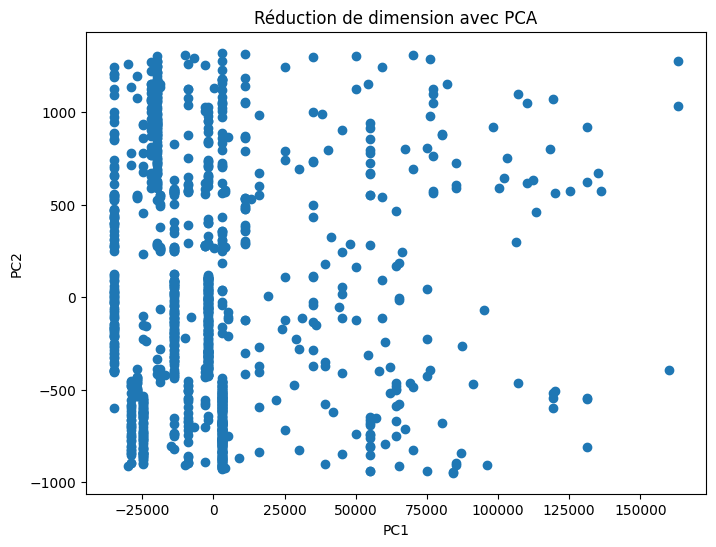


=== Résultat t-SNE ===
       TSNE1      TSNE2
0  75.149239   6.173622
1  42.568310  13.766235
2  35.855667 -12.943738
3  42.568630  13.773211
4  75.148331   6.173351


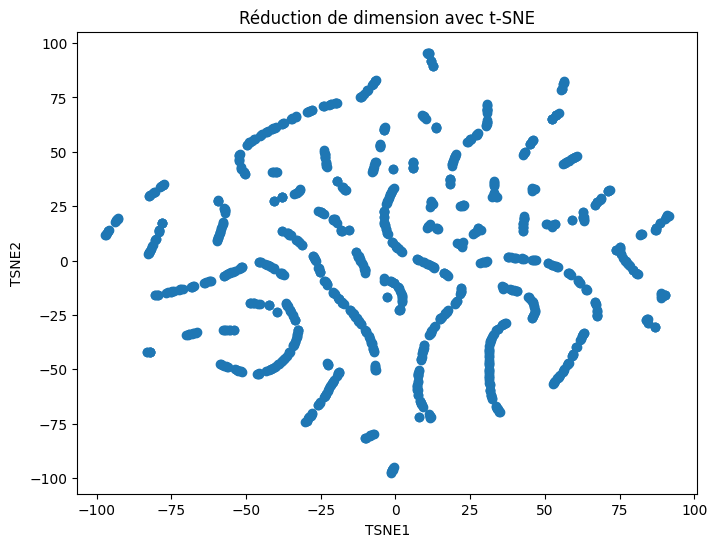

In [12]:
# Sélection des colonnes numériques
colonnes_numeriques = salary_data.select_dtypes(include=['int64', 'float64']).dropna(axis=1)

# ----- ACP (PCA) -----
pca = PCA(n_components=2)

composantes_pca = pca.fit_transform(colonnes_numeriques)

# Création d’un DataFrame PCA
salary_pca = pd.DataFrame(
    composantes_pca,
    columns=['PC1', 'PC2']
)

print("\n=== Résultat ACP ===")
print(salary_pca.head())

# Visualisation ACP

pca = PCA(n_components=2)

composantes_pca = pca.fit_transform(colonnes_numeriques)

# Création d’un DataFrame PCA
salary_pca = pd.DataFrame(
    composantes_pca,
    columns=['PC1', 'PC2']
)

print("\n=== Résultat ACP ===")
print(salary_pca.head())

# Visualisation ACP
plt.figure(figsize=(8,6))
plt.scatter(salary_pca['PC1'], salary_pca['PC2'])
plt.title("Réduction de dimension avec PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# t-SNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=5
)

composantes_tsne = tsne.fit_transform(colonnes_numeriques)

salary_tsne = pd.DataFrame(
    composantes_tsne,
    columns=['TSNE1', 'TSNE2']
)

print("\n=== Résultat t-SNE ===")
print(salary_tsne.head())

# Visualisation t-SNE
plt.figure(figsize=(8,6))
plt.scatter(salary_tsne['TSNE1'], salary_tsne['TSNE2'])
plt.title("Réduction de dimension avec t-SNE")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.show()


## Agrégation

In [ ]:
group_col = 'experience_level' if 'experience_level' in salary_data.columns else 'niveau_d_experience' if 'niveau_d_experience' in salary_data.columns else None
salary_col = 'salary' if 'salary' in salary_data.columns else 'salaire' if 'salaire' in salary_data.columns else None

if group_col is None or salary_col is None:
    raise KeyError("Required columns not found: expected one of ('experience_level','niveau_d_experience') and one of ('salary','salaire').")

aggregation = salary_data.groupby(group_col)[salary_col].agg(
    salaire_moyen='mean',
    salaire_median='median'
)

print("\n=== Average and median salary by experience level ===")
print(aggregation)


=== Salaire moyen et médian par niveau d'expérience ===
                  salaire_moyen  salaire_median
experience_level                               
Entry              36111.111111         30000.0
Executive          76076.923077         46000.0
Mid                51786.885246         51000.0
Senior             75088.033012         68000.0
